# 01. TPE Disk Tracking — StarDist

**Pipeline step 1 of 3** — detects photoelastic disks in each frame and links them into trajectories, then computes continuous rotation angles from UV images.

## Inputs
- Green-channel fluorescence images (`green_*.png`) — for disk detection
- UV/blue-channel images (`blue_*.png`) — for orientation tracking
- PE images (`bw_*.png`) — used for inspection only

## Outputs
- `<EXP_FOLDER>.pkl` — trajectory dataframe with columns:
  `frame, x, y, rpx, particle, boundary, angle`

## Workflow
1. Detect disks with StarDist2D → filter by area & eccentricity
2. Link detections into trajectories with Trackpy
3. Compute continuous rotation angles via PCA on UV images
4. Interpolate missing centroids or missing frame
5. Refine subpixel coordinates using convolution
6. Save trajectory to disk

### Imports

In [6]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os
import sys
from skimage import measure
from csbdeep.utils import normalize
from stardist.models import StarDist2D
import gc
import tensorflow as tf
import trackpy as tp

sys.path.insert(0, os.getcwd())
import src

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ModuleNotFoundError: No module named 'csbdeep'

### Camera Calibration 


In [2]:
def camera_align(I):
    """Apply perspective correction (calibrated 20260807)."""
    H = np.array([[ 1.00845132e+00,  2.00602917e-02, -7.44742561e+00],
       [-1.73536734e-02,  1.01552396e+00, -3.62908098e+01],
       [-2.76642447e-06,  7.60868700e-07,  1.00000000e+00]])
    height, width = I.shape[:2]
    return cv2.warpPerspective(I, H, (width, height))

### Parameters — edit here before running

In [3]:
IMG_DIR    = r'E:'
EXP_FOLDER = r'TPE_20260808A01_N=262x2_stop_go_1e-4rpsx2000s_stop1000s_1000framesx1fps_20reps'
PKL_DIR    = r'M:\Archive\Proj_TPE\Disk_traj_files'

roi = (250, 1200, 0, 2000)  # (y_min, y_max, x_min, x_max)

max_frame_bw   = int(src.max_num(IMG_DIR, EXP_FOLDER, 'bw_'))
max_frame_green = int(src.max_num(IMG_DIR, EXP_FOLDER, 'green_'))
max_frame_blue  = int(src.max_num(IMG_DIR, EXP_FOLDER, 'blue_'))
print(max_frame_bw, max_frame_green, max_frame_blue)
max_frame = max_frame_green

pickle_path = os.path.join(PKL_DIR, EXP_FOLDER)

print(f"Max frame:    {max_frame_green}")

# --- Log-spaced frame sampling ---
SAMPLE_LOG_FRAMES   = 1   # False to fall back to processing every frame
SKIP_ORIENTATION    = 1  # True if this dataset has no blue/UV orientation images
N_TRIALS            = 20
FRAMES_PER_TRIAL    = 1000
N_SAMPLE_PER_TRIAL  = 200

def log_sample(n_total, n_samples, start=1):
    n_request = n_samples
    while True:
        log_frames = np.logspace(np.log10(start), np.log10(n_total), n_request)
        frames = np.unique(np.round(log_frames).astype(int))
        if len(frames) >= n_samples:
            return frames[:n_samples] if len(frames) > n_samples else frames
        n_request += n_samples - len(frames) + 5

if SAMPLE_LOG_FRAMES:
    local_sample = log_sample(FRAMES_PER_TRIAL, N_SAMPLE_PER_TRIAL)
    local_sample[-1] = FRAMES_PER_TRIAL  # keep the true last frame of each trial

    frame_map = []  # (sample_idx, global_frame, trial, local_frame)
    sample_idx = 1
    for trial_idx in range(N_TRIALS):
        for local_frame in local_sample:
            global_frame = trial_idx * FRAMES_PER_TRIAL + int(local_frame)
            frame_map.append((sample_idx, global_frame, trial_idx, int(local_frame)))
            sample_idx += 1

    frame_map_df = pd.DataFrame(frame_map, columns=['sample_idx', 'global_frame', 'trial', 'local_frame'])
    global_to_sample = dict(zip(frame_map_df['global_frame'], frame_map_df['sample_idx']))
    frames_to_process_override = frame_map_df['global_frame'].tolist()

    print(f"Sampling {len(local_sample)} log-spaced frames/trial x {N_TRIALS} trials "
          f"= {len(frames_to_process_override)} frames total")

20000 20000 0
Max frame:    20000
Sampling 200 log-spaced frames/trial x 20 trials = 4000 frames total


### Load models

In [4]:
MODEL_DIR = os.path.join(os.getcwd(), 'models')
model_name = "stardist_09221229"
model = StarDist2D(None, name=model_name, basedir=MODEL_DIR)

Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.724202, nms_thresh=0.3.


### Load images and predict

Processing frame: 135WARNING:tensorflow:From c:\Users\R332-GH-PC\anaconda3\envs\stardist_env\Lib\site-packages\keras\src\backend\common\global_state.py:82: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.

Processing frame: 20000Frame: 3249 (orig 16049)


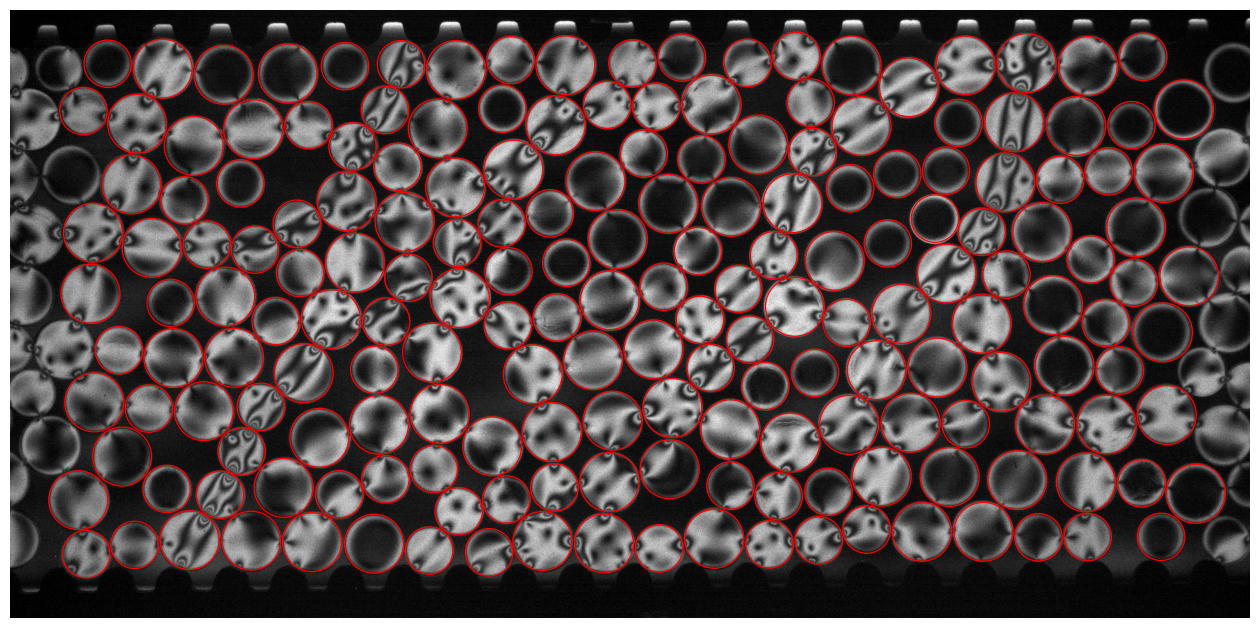

In [ ]:
axis_norm = (0,1)   # normalize channels independently

# Prepare DoG kernels for refinement
kernels = {
    46: src.dog_kernel(49, delta=3, sigma=2),
    37: src.dog_kernel(40, delta=3, sigma=2),
}

records = []  # empty list to store results temporarily

frames_to_process = frames_to_process_override if SAMPLE_LOG_FRAMES else list(range(1, max_frame + 1))
frame_count = 0

for frame in frames_to_process:
#for frame in [255]:
    # Load green images
    path = os.path.join(IMG_DIR, EXP_FOLDER, f'green_{frame:d}.png')
    I, err = src.read_image_with_retry(path)    
    if I is None:
        print(f"skipping frame {frame} (file not found)")
        continue
    if I.shape[2] == 3:  
        I = I[:,:,1]

    I = camera_align(cv2.flip(I, 1))
    
    sys.stdout.write(f"\rProcessing frame: {frame}")
    sys.stdout.flush()
    
    Ig = I[roi[0]:roi[1], roi[2]:roi[3]]  # GREEN CHANNEL 
    input_image = normalize(Ig, 1, 99.8, axis=axis_norm)
    
    # PREDICT 
    mask, detail = model.predict_instances(input_image, n_tiles=model._guess_n_tiles(input_image), show_tile_progress=False)

    # Compute properties
    props = measure.regionprops(mask)

    # Build temporary dataframe, filter, then apply DoG refinement
    frame_detections = []
    for region in props:
        y, x = region.centroid  # note: (row, col) = (y, x)
        area = region.area
        ecc = region.eccentricity
        
        # Filter: boundary check and eccentricity
        if not (100 < x < 1860 and y > 50 and ecc < 0.6):
            continue
        
        rpx = 46 if area >= 6000 else 37
        
        frame_detections.append({
            "log_sampled_frames": global_to_sample[frame] if SAMPLE_LOG_FRAMES else None,
            "frame": frame,
            "x": x,
            "y": y,
            "area": area,
            "ecc": ecc,
            "rpx": rpx
        })
    
    # Apply DoG refinement to filtered detections
    if frame_detections:
        temp_df = pd.DataFrame(frame_detections)
        # Pass zero-offset roi since coordinates are already relative to cropped image
        roi_cropped = (0, Ig.shape[0], 0, Ig.shape[1])
        refined = src.refine_frame_centers(temp_df, Ig, kernels, roi_cropped)
        records.extend(refined)

    # Delete large variables explicitly
    del I, Ig, input_image, mask, detail, props
    
    # Clear memory periodically
    frame_count += 1
    if frame_count % 100 == 0:
        gc.collect()
        tf.keras.backend.clear_session()

# Convert records to DataFrame
df_filtered = pd.DataFrame(records)

for col in ('frame', 'log_sampled_frames', 'rpx'):
    if col in df_filtered.columns:
        df_filtered[col] = df_filtered[col].astype(int)

src.visualize_detection(df_filtered, IMG_DIR, EXP_FOLDER, roi)

### Link coordinates into trajectory

In [ ]:
# Split df_filtered into segments (one per trial), link each separately,
# then recombine with offset particle IDs so identities never persist across boundaries.

if SAMPLE_LOG_FRAMES:
    N_SEGMENTS = N_TRIALS
    FRAMES_PER_SEG = N_SAMPLE_PER_TRIAL
else:
    N_SEGMENTS = 20
    FRAMES_PER_SEG = 1000

ID_OFFSET = 10000  # shift applied per segment to ensure unique particle IDs

df_filtered = df_filtered.copy()
df_filtered['_segment'] = (df_filtered['frame'] - 1) // FRAMES_PER_SEG

linked_segments = []
for seg_idx in range(N_SEGMENTS):
    df_seg = df_filtered[df_filtered['_segment'] == seg_idx].drop(columns='_segment').copy()

    linked_seg = tp.link(df_seg, search_range=30, memory=10)

    # Shift particle IDs so they are unique across segments
    linked_seg['particle'] = linked_seg['particle'] + seg_idx * ID_OFFSET

    if SAMPLE_LOG_FRAMES:
        # Preserve log_sampled_frames; frame stays as global frame number
        linked_seg['trial'] = seg_idx

    linked_segments.append(linked_seg)
    n_unique = df_seg['frame'].nunique()
    expected = FRAMES_PER_SEG
    flag = '' if n_unique == expected else f"  ⚠ expected {expected} unique frames, found {n_unique}"
    print(f"Segment {seg_idx}: frames {df_seg['frame'].min()}–{df_seg['frame'].max()}, "
          f"particles {linked_seg['particle'].nunique()}{flag}")

F_linked = pd.concat(linked_segments, ignore_index=True)

# Mark boundary particles
F_linked['boundary'] = (F_linked.x < 200) | (F_linked.x > 1770) | (F_linked.y < 120) | (F_linked.y > 800)

# Change radius to mode value for each particle
F_linked['rpx'] = F_linked.groupby('particle')['rpx'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else x)

Frame 4000: 192 trajectories present.
Segment 19: frames 3801–4000, particles 192


### Find rotation angles

incorporated from TPE_rotation_angle_finder

In [ ]:
records_rot = []

if SKIP_ORIENTATION:
    print("SKIP_ORIENTATION is True — no blue/UV images; skipping angle computation.")
    F_linked['dir_x'] = np.nan
    F_linked['dir_y'] = np.nan
    F_linked['angle'] = np.nan
else:
    if 'dir_x' not in F_linked.columns:
        F_linked['dir_x'] = np.nan
    if 'dir_y' not in F_linked.columns:
        F_linked['dir_y'] = np.nan

    group_cols = ['trial', 'frame'] if SAMPLE_LOG_FRAMES else ['frame']
    grouped_linked = F_linked.groupby(group_cols)

    for key in grouped_linked.groups:
        f = grouped_linked.get_group(key)

        if SAMPLE_LOG_FRAMES:
            trial, frame = key
            frame_orig = int(f['frame'].iloc[0])
            sys.stdout.write(f"\rProcessing trial {trial}, frame: {frame}")
        else:
            frame = key
            frame_orig = frame
            sys.stdout.write(f"\rProcessing frame: {frame}")
        sys.stdout.flush()

        path = os.path.join(IMG_DIR, EXP_FOLDER, f'blue_{frame_orig:d}.png')
        I, err = src.read_image_with_retry(path)  # ensure file exists before proceeding
        I = camera_align(cv2.flip(I, 1))

        if I.shape[2] == 3:  
            I = I[:,:,0]  # BLUE CHANNEL
        I = I[roi[0]:roi[1], roi[2]:roi[3]]  # BLUE CHANNEL

        records_rot.extend(src.compute_frame_orientations(f, I))

    # Bulk-assign all rotation results in one shot
    if records_rot:
        rot_df = pd.DataFrame(records_rot,
                              columns=['_idx', 'dir_x', 'dir_y', 'angle_R2']
                              ).set_index('_idx')
        F_linked.update(rot_df)

    F_linked = src.compute_continuous_angles(F_linked)

# --- Interpolate missing positions (and angles, if available) for all particles ---
# Runs regardless of SKIP_ORIENTATION: 'angle' is always present (real values or NaN
# placeholders), so interpolate_pos_angle never crashes on a missing column.
# 'frame' column is carried through automatically by interpolate_pos_angle
# itself via per-particle ffill/bfill operations.
frame_orig_fn = None
F_linked = src.interpolate_pos_angle(F_linked, frame_orig_fn=frame_orig_fn)

F_linked.drop(['dir_x', 'dir_y'], axis=1, inplace=True)

src.visualize_orientation(F_linked, IMG_DIR, EXP_FOLDER, roi, camera_align, SKIP_ORIENTATION)

SKIP_ORIENTATION is True — no blue/UV images; skipping angle computation.
Interpolated 61 missing positions.
SKIP_ORIENTATION is True — no angle data available to visualize.


### Compute per-particle G² 

Computing per-particle G²...
Trial 19, frame 200
G² computation complete.
Frame: 84 trial 8 (orig 8099)


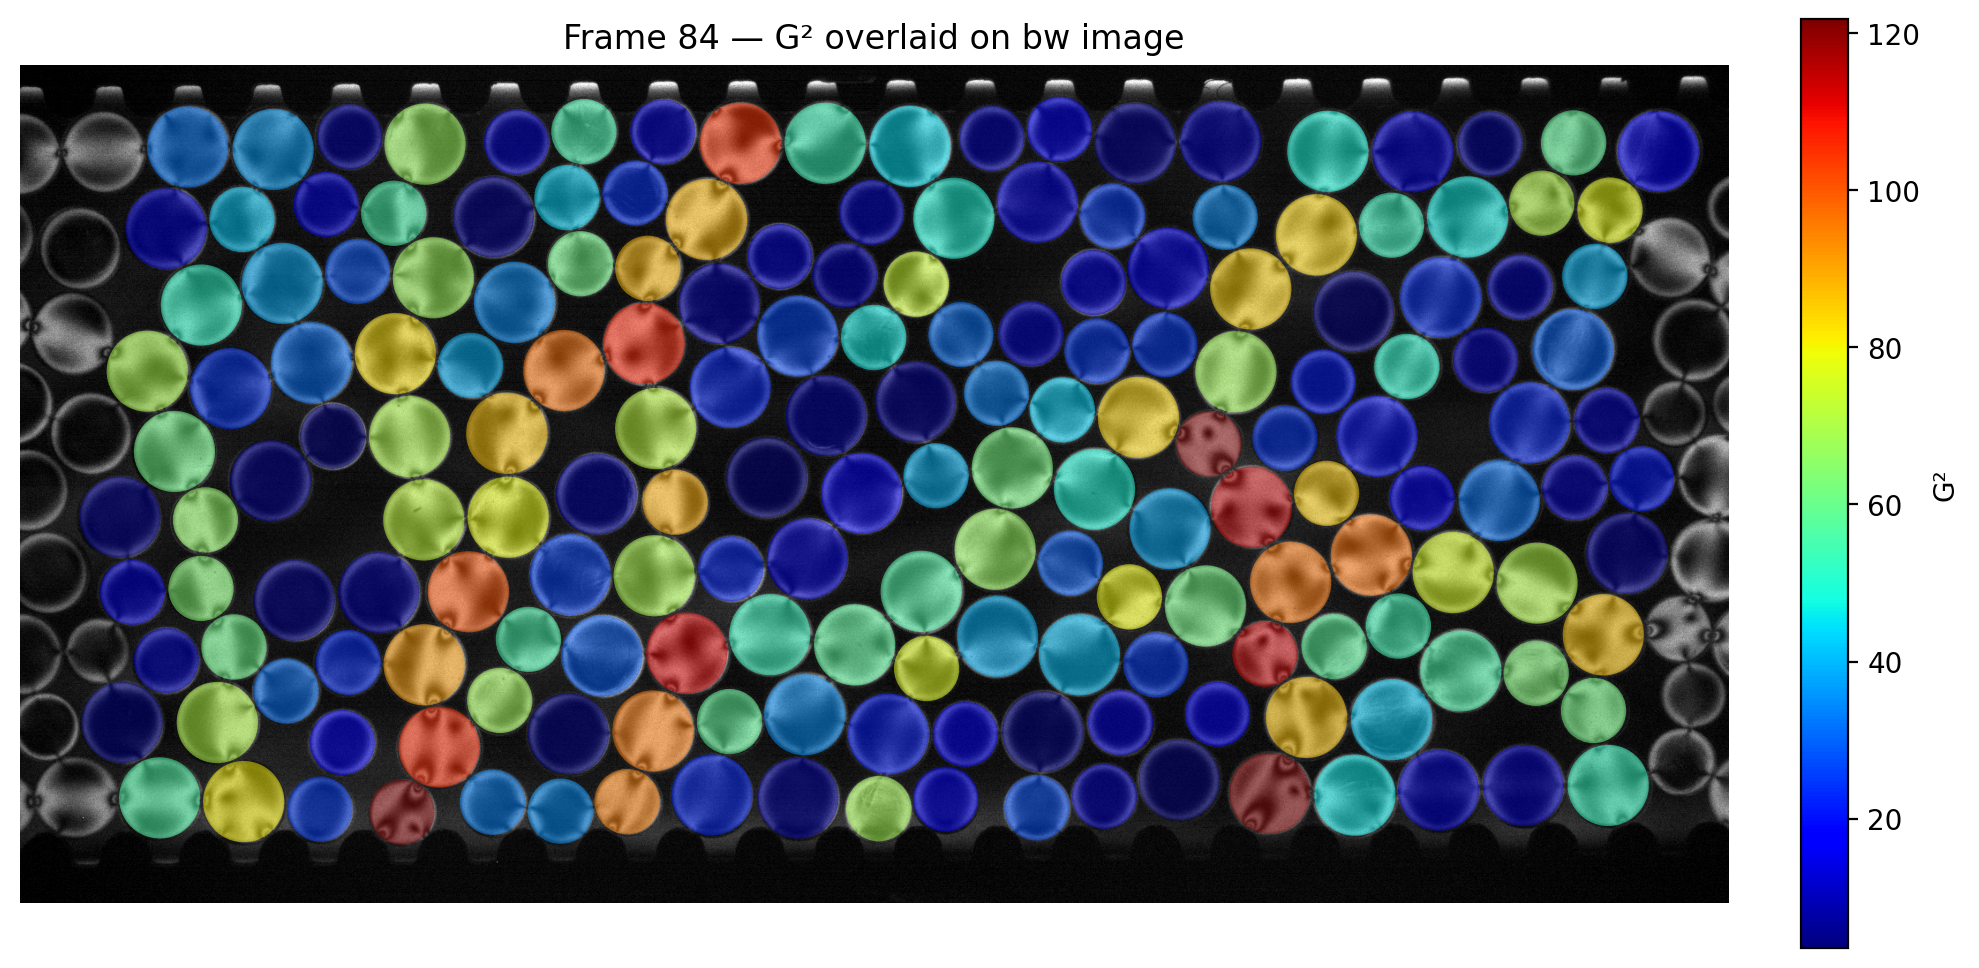

In [ ]:
# --- Per-particle G\u00b2 computation ---
# Uses src.compute_G2_map, src.subtract_gaussian_rings, src.crop_circle_with_mask_float
print("Computing per-particle G\u00b2...")
sigma_frac = 0.1

group_cols = ['trial', 'frame'] if SAMPLE_LOG_FRAMES else ['frame']
grouped_for_g2 = F_linked.groupby(group_cols)

for key in sorted(grouped_for_g2.groups.keys()):
    frame_data = grouped_for_g2.get_group(key)

    if SAMPLE_LOG_FRAMES:
        trial, frame = key
        frame_orig = int(frame_data['frame'].iloc[0])
        sys.stdout.write(f"\rTrial {trial}, frame {frame}")
    else:
        frame = key
        frame_orig = frame
        sys.stdout.write(f"\rFrame {frame}")
    sys.stdout.flush()

    image_path = os.path.join(IMG_DIR, EXP_FOLDER, f'bw_{frame_orig}.png')
    img, err = src.read_image_with_retry(image_path)
    if img is None:
        print(f"\nWarning: could not load {image_path}, skipping.")
        continue

    img = img[roi[0]:roi[1], roi[2]:roi[3]]

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 1).astype(np.float32)
    gray = gray / gray.max()
    gray = src.subtract_gaussian_rings(gray, frame_data, sigma_frac=sigma_frac)

    G2_map = src.compute_G2_map(gray)
    h, w = G2_map.shape

    for idx, row in frame_data.iterrows():
        x = int(np.around(float(row['x'])))
        y = int(np.around(float(row['y'])))
        r = int(row['rpx'])
        y1, y2 = max(0, y - r), min(h, y + r)
        x1, x2 = max(0, x - r), min(w, x + r)
        if (y2 - y1) == 0 or (x2 - x1) == 0:
            F_linked.at[idx, 'G2'] = np.nan
            continue
        G2_crop = src.crop_circle_with_mask_float(G2_map[y1:y2, x1:x2])
        F_linked.at[idx, 'G2'] = float(np.sum(G2_crop[G2_crop > 0]))

print("\nG\u00b2 computation complete.")

src.visualize_g2(F_linked, IMG_DIR, EXP_FOLDER, roi)

### save to disk

In [10]:
if SAMPLE_LOG_FRAMES:
    F_linked.to_pickle(str(pickle_path+'_logframes.pkl'))
else:
    F_linked.to_pickle(str(pickle_path+'.pkl'))